# Loan Approval Prediction 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [7]:
df = pd.read_csv(r"C:\Users\sakshi fauzdar\Downloads\loan_dataset.csv")

In [9]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [12]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 614
Number of columns: 13


In [11]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [13]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [14]:
# --- fill missing TEXT columns with the most common value (mode) ---
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

# --- fill missing NUMBER columns with the median (middle value) ---
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].median())

# let's double check there are no missing values left
df.isnull().sum()


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [15]:
df["Dependents"] = df["Dependents"].replace("3+", "3").astype(int)

df["Dependents"].value_counts()


Dependents
0    360
1    102
2    101
3     51
Name: count, dtype: int64

In [16]:
# count how many "Y" (approved) and "N" (not approved) we have
df["Loan_Status"].value_counts()


Loan_Status
Y    422
N    192
Name: count, dtype: int64

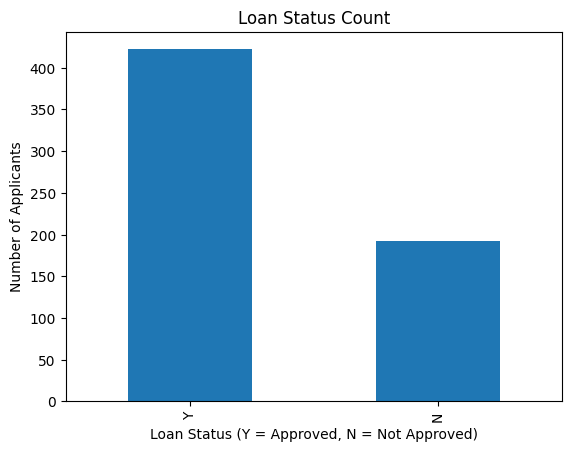

In [17]:
# draw a simple bar chart of the counts above
df["Loan_Status"].value_counts().plot(kind="bar")
plt.title("Loan Status Count")
plt.xlabel("Loan Status (Y = Approved, N = Not Approved)")
plt.ylabel("Number of Applicants")
plt.show()


In [18]:
# group the data by credit history and loan status, then count
df.groupby(["Credit_History", "Loan_Status"]).size()


Credit_History  Loan_Status
0.0             N               82
                Y                7
1.0             N              110
                Y              415
dtype: int64

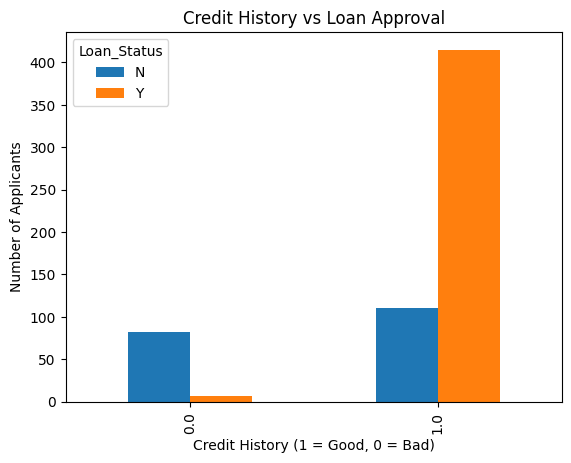

In [19]:
# a simple chart: for each credit history value, how many were approved/not approved
pd.crosstab(df["Credit_History"], df["Loan_Status"]).plot(kind="bar")
plt.title("Credit History vs Loan Approval")
plt.xlabel("Credit History (1 = Good, 0 = Bad)")
plt.ylabel("Number of Applicants")
plt.show()


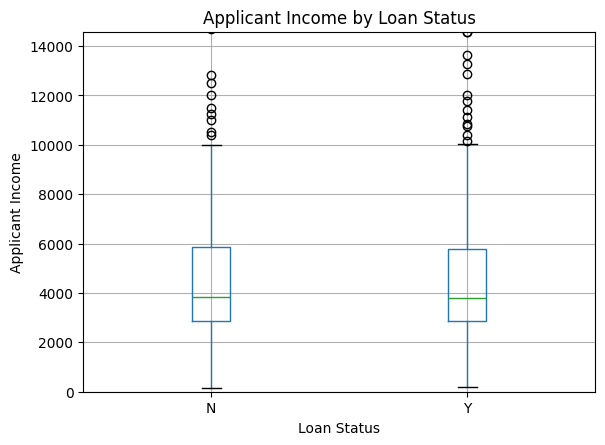

In [20]:
# a simple chart comparing income for each loan status
df.boxplot(column="ApplicantIncome", by="Loan_Status")
plt.title("Applicant Income by Loan Status")
plt.suptitle("")  # removes the automatic subtitle pandas adds
plt.xlabel("Loan Status")
plt.ylabel("Applicant Income")
plt.ylim(0, df["ApplicantIncome"].quantile(0.95))  # zoom in, ignore a few extreme outliers
plt.show()


In [22]:
# let's see which columns are still text before we convert them
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents             int64
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

In [23]:
# the Loan_ID column is just a unique label for each row (like a name tag) -
# it doesn't help the model make predictions, so we drop it
df = df.drop("Loan_ID", axis=1)

# convert text columns into 0s and 1s
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["Married"] = df["Married"].map({"Yes": 1, "No": 0})
df["Education"] = df["Education"].map({"Graduate": 1, "Not Graduate": 0})
df["Self_Employed"] = df["Self_Employed"].map({"Yes": 1, "No": 0})
df["Property_Area"] = df["Property_Area"].map({"Urban": 2, "Semiurban": 1, "Rural": 0})

# convert our target column: Y -> 1 (approved), N -> 0 (not approved)
df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})

df.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1


In [24]:
# X = all columns except Loan_Status (these are our "inputs")
X = df.drop("Loan_Status", axis=1)

# y = only the Loan_Status column (this is what we want to predict)
y = df["Loan_Status"]

print("X (inputs) shape:", X.shape)
print("y (target) shape:", y.shape)


X (inputs) shape: (614, 11)
y (target) shape: (614,)


Now we split our data into a **training set** and a **testing set**:
- The model *learns* from the training set
- We *test* how good the model is on the testing set (data it has never seen)

We'll use 80% of the data for training and 20% for testing.


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% of data goes to testing
    random_state=42    # makes the split repeatable/consistent every time
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


Training rows: 491
Testing rows: 123


#Train the Model

We'll use **Logistic Regression** — a simple and popular algorithm for
"yes/no" style predictions (binary classification).

Training a model in scikit-learn always follows the same 2 steps:
1. Create the model
2. Call `.fit()` to let it learn from the training data


In [26]:
# step 1: create the model
# max_iter is raised a bit so the model has enough attempts to fully learn
model = LogisticRegression(max_iter=1000)

# step 2: train it using our training data
model.fit(X_train, y_train)

print("Model training complete!")


Model training complete!


c:\Users\sakshi fauzdar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#Make Predictions

Now that the model has learned patterns from the training data, let's use
it to predict loan approval for the **test data** (which it has never seen).


In [27]:
# ask the model to predict Loan_Status for the test data
y_pred = model.predict(X_test)

# let's compare a few actual vs predicted values
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})
comparison


,Actual,Predicted
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,0,1
9,0,1


#Evaluate the Model

Now we check *how good* our model actually is, using a few standard metrics:

- **Accuracy** — what % of predictions were correct overall
- **Confusion Matrix** — a table showing correct vs incorrect predictions
- **Classification Report** — precision, recall, and f1-score in one view


In [29]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")


Accuracy: 78.86 %


In [30]:
# the confusion matrix shows:
# [ [correctly predicted "Not Approved", wrongly predicted "Approved"]
#   [wrongly predicted "Not Approved", correctly predicted "Approved"] ]
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[18 25]
 [ 1 79]]


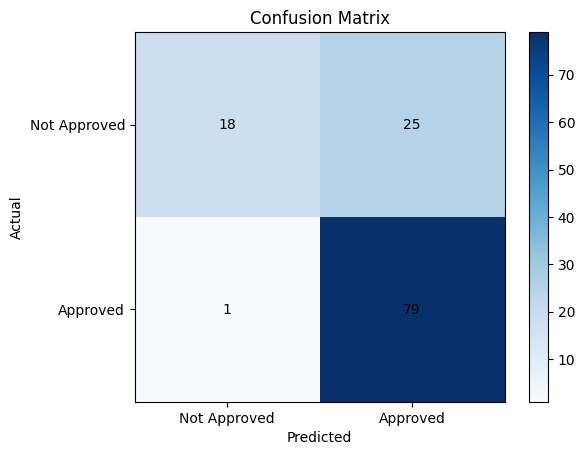

In [31]:
# a nicer visual version of the confusion matrix
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Not Approved", "Approved"])
plt.yticks([0, 1], ["Not Approved", "Approved"])

# write the numbers on top of each square
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


In [32]:
# precision, recall, f1-score for both classes in one summary
print(classification_report(y_test, y_pred, target_names=["Not Approved", "Approved"]))


              precision    recall  f1-score   support

Not Approved       0.95      0.42      0.58        43
    Approved       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



**How reading these metrics:**
- **Precision** — of everyone the model *predicted* as approved, how many were *actually* approved
- **Recall** — of everyone who was *actually* approved, how many did the model *catch*
- **F1-score** — a balance between precision and recall (higher is better)


#Conclusion:

- We built a simple model that predicts loan approval using real applicant
  data — income, loan amount, credit history, and a few other features.
- We saw that **credit history** tends to have a strong effect on approval
  — this matches how real banks make decisions.
- ML workflow in this project is:
  **load data → clean it → explore it → prepare it → train a model → check
  how good it is**.